# 03 — Configuration 3 — Channel independence: PatchTST-CI vs PatchTST-CA

**Question.** Do the covariates (grid, cyclic, solar geometry) improve the forecast, and how should they be injected?

**Hypotheses.** **CI**: shared encoder, only the target channel feeds the head: the exogenous channels have no influence (univariate equivalent). **CA**: cross-channel attention at each patch: the target "queries" the past exogenous channels. **X**: the FUTURE deterministic covariates (hour, season, solar geometry of the forecast instant) correct the forecast step by step. **g**: physical gate: the forecast is forced to 0 when the sun is down.

**Fixed parameters.** P and L selected in configurations 1 and 2, H = 24 h.

**Protocol** (identical for every configuration — module `patchtst_pv`, section 8):
1. training on Train (2019–2021), early stopping on Val (01–09/2022), **5 seeds**;
2. accuracy on **every hourly origin of the Test set** (10/2022–05/2023): RMSE, MAE, nRMSE = RMSE / mean, R², MBE;
3. **robustness**: standard deviation over the seeds and 5 % Gaussian noise on the exogenous channels (rejected if ΔRMSE > 15 %);
4. **stability**: 30-day rolling forecast without re-training, drift = RMSE(D24–30) / RMSE(D1–7) (target < 1.2);
5. **efficiency**: inference time for one sample (< 100 ms) and weight size (< 50 MB);
6. **decision score** of `projet.md` (raw and normalised) and Diebold-Mariano tests against persistence and the 7-day mean.

> Trainings are cached (`cache/<configuration>/`): deleting the corresponding folder re-runs the full
> training from this notebook.

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)
import analysis as an, flowchart as fc, json, dataclasses
from nb_config import configs_for

## 1. Flowchart of the configuration

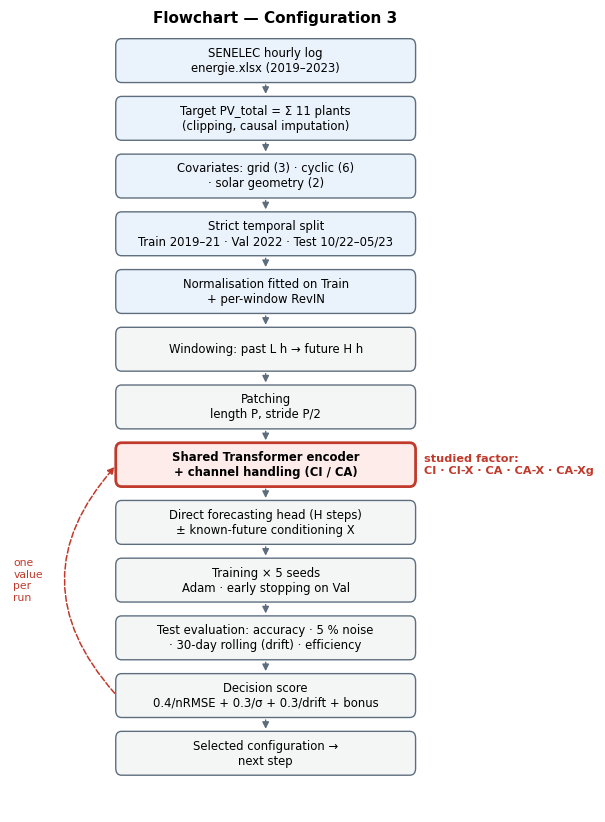

In [2]:
fc.draw(3, "Flowchart — Configuration 3", "flow_config3")

## 2. Configurations evaluated

In [3]:
ds = m.build_dataset()
configs = configs_for(3)
pd.DataFrame([dict(name=c.name(), P=c.P, L=c.L, H=c.H, channels=c.channel_mode, known_future=c.known_future,
                   physical_gate=c.physical_gate, n_patches=c.n_patches) for c in configs])

,name,P,L,H,channels,known_future,physical_gate,n_patches
0,PatchTST-CI_P12_L168_H24,12,168,24,CI,False,False,27
1,PatchTST-CIX_P12_L168_H24,12,168,24,CI,True,False,27
2,PatchTST-CA_P12_L168_H24,12,168,24,CA,False,False,27
3,PatchTST-CAX_P12_L168_H24,12,168,24,CA,True,False,27
4,PatchTST-CAXg_P12_L168_H24,12,168,24,CA,True,True,27


## 3. Training and evaluation (5 seeds each)

In [4]:
results = [m.evaluate_configuration(c, ds) for c in configs]   # reads the cache if it exists
detail = pd.DataFrame([dict(configuration=r["name"], **{k: g[k] for k in
         ["seed", "epochs", "duration_s", "RMSE", "MAE", "nRMSE", "R2", "noise_degradation", "drift_7d", "drift_D30_D1"]})
         for r in results for g in r["per_seed"]])
detail

,configuration,seed,epochs,duration_s,RMSE,MAE,nRMSE,R2,noise_degradation,drift_7d,drift_D30_D1
0,PatchTST-CI_P12_L168_H24,0,13,871.6904,9.4293,5.6644,0.2130,0.9715,0.0000e+00,0.5874,0.5563
1,PatchTST-CI_P12_L168_H24,1,13,870.6330,9.4029,5.5093,0.2124,0.9716,0.0000e+00,0.5725,0.4917
2,PatchTST-CI_P12_L168_H24,2,8,25.7582,9.6188,5.4987,0.2173,0.9703,0.0000e+00,0.5651,0.5301
3,PatchTST-CI_P12_L168_H24,3,12,38.9990,9.4124,5.4662,0.2127,0.9716,0.0000e+00,0.5662,0.5478
4,PatchTST-CI_P12_L168_H24,4,9,28.7573,9.4748,5.2501,0.2141,0.9712,0.0000e+00,0.5458,0.5510
5,PatchTST-CIX_P12_L168_H24,0,17,56.5129,9.0164,5.2678,0.2037,0.9739,3.6213e-03,0.5912,0.5230
6,PatchTST-CIX_P12_L168_H24,1,20,68.5410,9.1419,5.3381,0.2065,0.9732,2.5127e-03,0.6318,0.5652
7,PatchTST-CIX_P12_L168_H24,2,20,67.7192,9.0923,5.5456,0.2054,0.9735,4.5106e-03,0.5844,0.5124
8,PatchTST-CIX_P12_L168_H24,3,10,33.4134,9.4059,5.5507,0.2125,0.9716,1.9504e-03,0.6340,0.5166
9,PatchTST-CIX_P12_L168_H24,4,25,84.1386,8.8887,5.3071,0.2008,0.9746,3.6989e-03,0.5848,0.5125


## 4. Comparison table of the metrics (mean over 5 seeds) and naive baselines

In [5]:
table = m.comparison_table(results)
_, true0, orig0 = an.load_predictions(results[0]["name"])
refs = an.baseline_rows(ds, orig0, true0, configs[0].H) if len({c.H for c in configs}) == 1 else None
columns = ["configuration", "RMSE", "RMSE_std", "MAE", "nRMSE", "nRMSE_day", "R2", "MBE", "noise_degradation",
           "drift_D30_D1", "drift_7d", "inference_ms", "size_MB", "n_parameters", "score", "normalised_score", "rejected_noise"]
shown = pd.concat([table[columns], refs], ignore_index=True) if refs is not None else table[columns]
m.TABLES_DIR.mkdir(exist_ok=True)
shown.to_csv(m.TABLES_DIR / "table_config3.csv", index=False)
shown.round(4)

,configuration,RMSE,RMSE_std,MAE,nRMSE,nRMSE_day,R2,MBE,noise_degradation,drift_D30_D1,drift_7d,inference_ms,size_MB,n_parameters,score,normalised_score,rejected_noise
0,PatchTST-CI_P12_L168_H24,9.4676,0.0889,5.4778,0.2139,0.2294,0.9712,0.4551,0.0000,0.5354,0.5674,0.9184,0.4346,111066.0,5.9729,0.4000,False
1,PatchTST-CIX_P12_L168_H24,9.1091,0.1915,5.4019,0.2058,0.2146,0.9734,-0.5225,0.0033,0.5259,0.6052,1.1368,0.6580,169147.0,4.2062,0.5236,False
2,PatchTST-CA_P12_L168_H24,9.3863,0.2476,5.6622,0.2121,0.2207,0.9717,0.4390,-0.0003,0.5962,0.5885,2.5394,0.5031,128544.0,3.8078,0.1720,False
3,PatchTST-CAX_P12_L168_H24,9.0158,0.0974,5.2086,0.2037,0.2146,0.9739,-0.0050,0.0044,0.5752,0.5839,2.9255,0.7265,186625.0,5.7561,0.7839,False
4,PatchTST-CAXg_P12_L168_H24,9.0172,0.0944,5.2106,0.2037,0.2146,0.9739,-0.0161,1.1204,0.5777,0.5858,2.6275,0.7265,186625.0,5.8549,0.7885,True
5,Persistence D-1,10.3923,0.0000,4.9667,0.2348,NaN,0.9653,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7-day mean,10.8215,0.0000,5.3064,0.2445,NaN,0.9624,-0.0260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Reading the columns.* `RMSE_std`: standard deviation over the 5 seeds (robustness). `nRMSE_day`: nRMSE restricted to
daytime hours. `noise_degradation`: relative RMSE increase under 5 % noise on the exogenous channels. `drift_D30_D1`: raw
ratio of `projet.md` (sensitive to the cloudiness of two isolated days); `drift_7d`: smoothed ratio used in the score.
`score`: raw formula of `projet.md`; `normalised_score`: each criterion mapped to [0, 1] across the compared variants.

In [6]:
dm = an.dm_tests(ds, results)
dm.round(4)

,configuration,reference,skill_score,DM,p_value
0,PatchTST-CI_P12_L168_H24,persistence,0.0927,-2.0976,0.0360
1,PatchTST-CI_P12_L168_H24,7-day mean,0.1287,-2.8080,0.0050
2,PatchTST-CIX_P12_L168_H24,persistence,0.1251,-2.9107,0.0036
3,PatchTST-CIX_P12_L168_H24,7-day mean,0.1598,-2.9420,0.0033
4,PatchTST-CA_P12_L168_H24,persistence,0.1078,-2.4055,0.0162
5,PatchTST-CA_P12_L168_H24,7-day mean,0.1432,-2.9732,0.0030
6,PatchTST-CAX_P12_L168_H24,persistence,0.1314,-2.9661,0.0030
7,PatchTST-CAX_P12_L168_H24,7-day mean,0.1659,-3.0762,0.0021
8,PatchTST-CAXg_P12_L168_H24,persistence,0.1314,-2.9661,0.0030
9,PatchTST-CAXg_P12_L168_H24,7-day mean,0.1659,-3.0762,0.0021


## 5. Seed rosary and 30-day stability

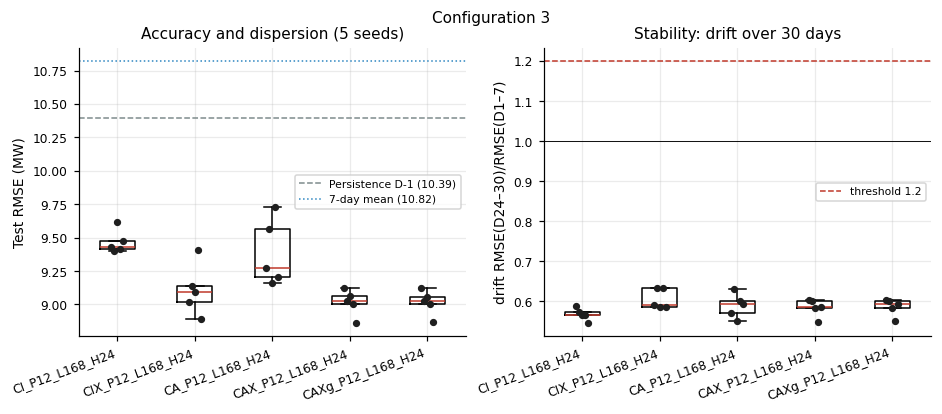

In [7]:
an.fig_rosary(results, ds, "fig_config3_rosary", "Configuration 3")

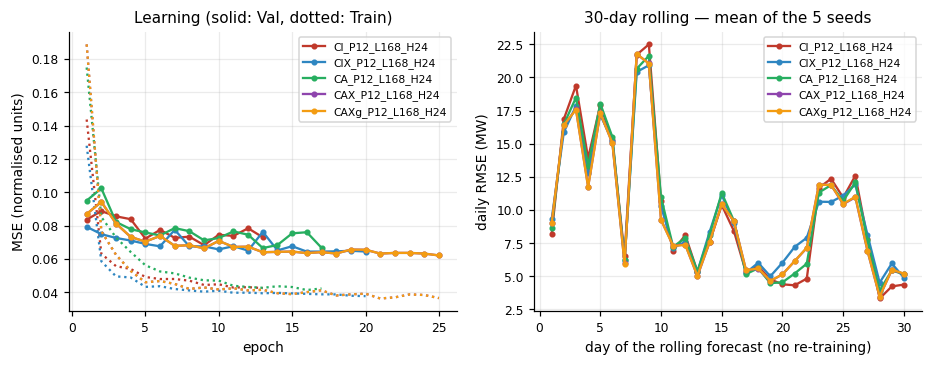

In [8]:
an.fig_learning_and_drift(results, "fig_config3_learning_drift")

## 6. Observed vs predicted series — best model of the configuration

Selected configuration: PatchTST-CAX_P12_L168_H24


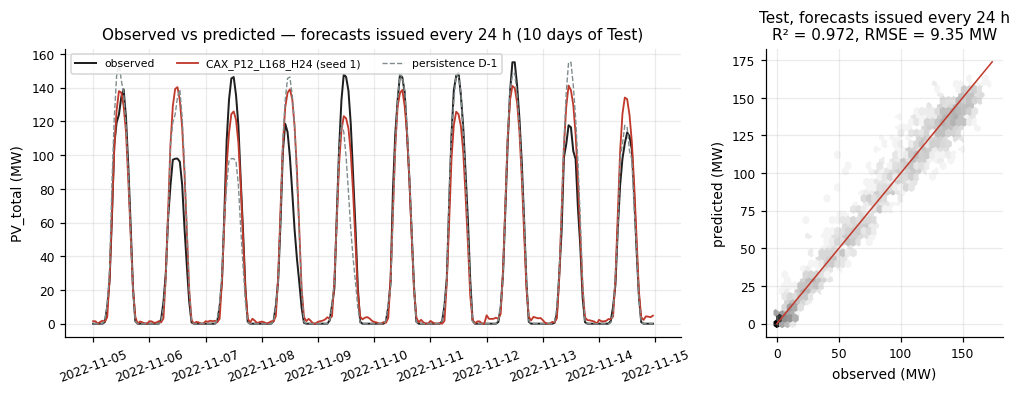

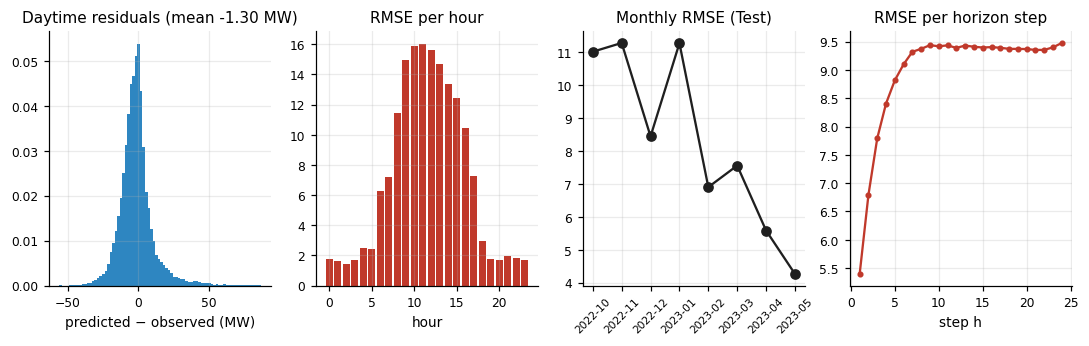

In [9]:
selected = an.selected_at("config3_channels")
print("Selected configuration:", selected)
res_selected = [r for r in results if r["name"] == selected][0]
an.fig_observed_vs_predicted(res_selected, ds, "fig_config3_observed_predicted")
an.fig_residuals(res_selected, ds, "fig_config3_residuals")

### Conclusion of configuration 3

**Selected configuration: `PatchTST-CAX_P12_L168_H24`** (normalised decision score = 0.784; raw score = 5.76).

- `PatchTST-CI_P12_L168_H24`: RMSE = 9.47 ± 0.09 MW, nRMSE = 0.214, gain vs persistence = +8.9 %, degradation under noise = +0.0 %, 7-day drift = 0.57, inference = 0.9 ms, 111,066 parameters.
- `PatchTST-CIX_P12_L168_H24`: RMSE = 9.11 ± 0.19 MW, nRMSE = 0.206, gain vs persistence = +12.3 %, degradation under noise = +0.3 %, 7-day drift = 0.61, inference = 1.1 ms, 169,147 parameters.
- `PatchTST-CA_P12_L168_H24`: RMSE = 9.39 ± 0.25 MW, nRMSE = 0.212, gain vs persistence = +9.7 %, degradation under noise = -0.0 %, 7-day drift = 0.59, inference = 2.5 ms, 128,544 parameters.
- `PatchTST-CAX_P12_L168_H24`: RMSE = 9.02 ± 0.10 MW, nRMSE = 0.204, gain vs persistence = +13.2 %, degradation under noise = +0.4 %, 7-day drift = 0.58, inference = 2.9 ms, 186,625 parameters.
- `PatchTST-CAXg_P12_L168_H24`: RMSE = 9.02 ± 0.09 MW, nRMSE = 0.204, gain vs persistence = +13.2 %, degradation under noise = +112.0 %, 7-day drift = 0.59, inference = 2.6 ms, 186,625 parameters.

- RMSE gap between the best and the worst variant: 0.45 MW (5.0 %).
- All variants meet the robustness criterion (degradation < 15 %): no; all meet the drift target < 1.2: yes; all meet the efficiency targets (< 100 ms, < 50 MB): yes.